In [8]:
# Celda tipo code (Python)
!pip install pandas numpy matplotlib seaborn plotly networkx python-louvain pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 87.2 MB/s eta 0:00:00


In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import networkx as nx
from collections import Counter
from itertools import combinations
from pyvis.network import Network
import community as community_louvain  # para detección de comunidades (Louvain)

# Opcional: mejorar estilo plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# Crear carpeta de outputs
os.makedirs("outputs", exist_ok=True)

In [10]:
# carga
csv_path = "scopus.csv"
df = pd.read_csv(csv_path, dtype=str, low_memory=False)

# Limpieza inicial de nombres de columnas
df.columns = [c.strip() for c in df.columns]

print("Filas, columnas:", df.shape)
print("Columnas:")
print(df.columns.tolist())

# Mostrar primeras filas
df.head(3)

Filas, columnas: (119, 45)
Columnas:
['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year', 'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end', 'Cited by', 'DOI', 'Link', 'Affiliations', 'Authors with affiliations', 'Abstract', 'Author Keywords', 'Index Keywords', 'Molecular Sequence Numbers', 'Chemicals/CAS', 'Tradenames', 'Manufacturers', 'Funding Details', 'Funding Texts', 'References', 'Correspondence Address', 'Editors', 'Publisher', 'Sponsors', 'Conference name', 'Conference date', 'Conference location', 'Conference code', 'ISSN', 'ISBN', 'CODEN', 'PubMed ID', 'Language of Original Document', 'Abbreviated Source Title', 'Document Type', 'Publication Stage', 'Open Access', 'Source', 'EID']


,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,ISBN,CODEN,PubMed ID,Language of Original Document,Abbreviated Source Title,Document Type,Publication Stage,Open Access,Source,EID
0,Córdova-Berona H.A.; Nuñez Diaz L.A.; Vargas C...,"Córdova-Berona, Helí Alejandro (58029958700); ...",58029958700; 60466516900; 60466126800; 5793096...,Optimizing Healthcare Delivery with a Generati...,2025,Proceedings of the LACCEI international Multi-...,NaN,NaN,NaN,NaN,...,978-628966132-3,NaN,NaN,Spanish,Proc. LACCEI int. multi-conf. eng. educ. technol.,Conference paper,Final,All Open Access; Gold Open Access,Scopus,2-s2.0-105032444908
1,Leiva-Guerrero M.V.; Zamorano I.A.; Collins R....,"Leiva-Guerrero, María Verónica (57216896200); ...",57216896200; 60407786400; 60407197600; 6040749...,Feedback on learning with generative artificia...,2026,RIED-Revista Iberoamericana de Educacion a Dis...,29,1,NaN,241,...,NaN,NaN,NaN,Spanish,RIED Rev. Iberoam. Educ. Distancia.,Article,Final,All Open Access; Gold Open Access; Green Open ...,Scopus,2-s2.0-105030562559
2,Berdasco-Gancedo Y.; Prieto-Preboste S.,"Berdasco-Gancedo, Yolanda (55772022200); Priet...",55772022200; 56256472300,Impact of Generative Artificial Intelligence o...,2025,BiD,NaN,54,NaN,NaN,...,NaN,NaN,NaN,English,BiD,Article,Final,All Open Access; Gold Open Access; Green Open ...,Scopus,2-s2.0-105018952275


In [11]:
# Normalizar Year a numérico si existe
if 'Year' in df.columns:
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Función robusta para convertir campo en lista
def split_to_list(s, sep=';'):
    if pd.isna(s):
        return []
    # A veces los separadores pueden ser ';' o ',' - probamos ambos
    if sep in s:
        parts = [x.strip() for x in s.split(sep)]
    elif ',' in s and ';' not in s:
        parts = [x.strip() for x in s.split(',')]
    else:
        parts = [s.strip()]
    return [p for p in parts if p]

# Crear columnas listas
authors_col = 'Authors' if 'Authors' in df.columns else None
keywords_col = None
# Detectar columna de keywords más probable
for candidate in ['Author Keywords','Author Keywords ','DE','Author Keywords (ID)']:
    if candidate in df.columns:
        keywords_col = candidate
        break

df['Author_list'] = df[authors_col].apply(lambda s: split_to_list(s, sep=';')) if authors_col else [[]]*len(df)
df['Keywords_list'] = df[keywords_col].fillna('').apply(lambda s: [kw.strip().lower() for kw in split_to_list(s, sep=';')]) if keywords_col else [[]]*len(df)

# Preview
print("Ejemplo de autores y keywords:")
df[['Author_list','Keywords_list']].head(5)

Ejemplo de autores y keywords:


,Author_list,Keywords_list
0,"[Córdova-Berona H.A., Nuñez Diaz L.A., Vargas ...","[chatbot, conversational agents, generative ar..."
1,"[Leiva-Guerrero M.V., Zamorano I.A., Collins R...","[chatgpt, chatgpt, escalera de wilson, estudia..."
2,"[Berdasco-Gancedo Y., Prieto-Preboste S.]","[digital education, educational podcasting, ge..."
3,"[García-Peñalvo F.J., Llorens-Largo F., Vidal J.]","[artificial intelligence, chatgpt, education, ..."
4,"[Puentes G., Espinosa O., Gutiérrez J.D.]",[]


In [12]:
# Top keywords
kw_counter = Counter([kw for sub in df['Keywords_list'] for kw in sub])
top_kw = kw_counter.most_common(30)
pd.DataFrame(top_kw, columns=['keyword','count']).to_csv("outputs/top_keywords.csv", index=False)
print("Top 10 keywords:", top_kw[:10])

# Top authors (por número de apariciones)
author_counter = Counter([a for sub in df['Author_list'] for a in sub])
top_authors = author_counter.most_common(30)
pd.DataFrame(top_authors, columns=['author','count']).to_csv("outputs/top_authors.csv", index=False)
print("Top 10 authors:", top_authors[:10])

# Top fuentes (Source title / SO)
if 'Source title' in df.columns:
    top_sources = df['Source title'].fillna('Unknown').str.strip().value_counts().reset_index()
    top_sources.columns = ['source','count']
    top_sources.head(20).to_csv("outputs/top_sources.csv", index=False)
    print("Top sources saved to outputs/top_sources.csv")

# Publicaciones por año
if 'Year' in df.columns:
    pubs_per_year = df.groupby('Year').size().reset_index(name='n_pubs').sort_values('Year')
    pubs_per_year.to_csv("outputs/pubs_per_year.csv", index=False)
    fig = px.bar(pubs_per_year, x='Year', y='n_pubs', title='Publicaciones por año')
    fig.write_html("outputs/pubs_per_year.html")
    fig.show()
else:
    print("No hay columna 'Year' para series temporales.")

Top 10 keywords: [('generative artificial intelligence', 106), ('artificial intelligence', 26), ('chatgpt', 23), ('higher education', 23), ('inteligencia artificial generativa', 9), ('education', 8), ('ethics', 6), ('teacher training', 6), ('educational innovation', 6), ('large language models', 4)]
Top 10 authors: [('Codina L.', 3), ('Rojas-Contreras M.', 3), ('García-Peñalvo F.J.', 2), ('Llorens-Largo F.', 2), ('Peña-Fernández S.', 2), ('Palacios C.R.', 2), ('Palacios E.L.', 2), ('Álvarez F.D.', 2), ('García-López I.M.', 2), ('Ramírez-Montoya M.S.', 2)]
Top sources saved to outputs/top_sources.csv


In [13]:
# Seleccionar top N keywords y mostrar su evolución por año
top_n = 8
top_keywords_list = [k for k,_ in top_kw[:top_n]]

# Construir tabla keyword x year
rows = []
for _, row in df.iterrows():
    year = row.get('Year', np.nan)
    if np.isnan(year):
        continue
    kws = row['Keywords_list']
    for kw in kws:
        if kw in top_keywords_list:
            rows.append({'Year': int(year), 'keyword': kw})

kw_year_df = pd.DataFrame(rows)
if not kw_year_df.empty:
    kw_trend = kw_year_df.groupby(['Year','keyword']).size().reset_index(name='count')
    fig = px.line(kw_trend, x='Year', y='count', color='keyword', markers=True, title='Evolución temporal de top keywords')
    fig.write_html("outputs/keyword_trends.html")
    fig.show()
else:
    print("No hay datos suficientes para trends de keywords.")

In [14]:
# Construir grafo: cada autor un nodo, arista entre coautores con peso = num. papers compartidos
G = nx.Graph()

for authors in df['Author_list']:
    # ignorar listas vacías
    if len(authors) <= 1:
        # si 1 autor, asegurar nodo
        if len(authors)==1:
            a = authors[0]
            if not G.has_node(a):
                G.add_node(a)
        continue
    # crear combinaciones
    for a,b in combinations(authors, 2):
        if a==b:
            continue
        if G.has_edge(a,b):
            G[a][b]['weight'] += 1
        else:
            G.add_edge(a,b, weight=1)

print("Nodos:", G.number_of_nodes(), "Aristas:", G.number_of_edges())

# Calcular métricas: degree weighted, betweenness
deg = sorted(G.degree(weight='weight'), key=lambda x: x[1], reverse=True)[:30]
pd.DataFrame(deg, columns=['author','weighted_degree']).to_csv("outputs/top_degree_authors.csv", index=False)
print("Top degree authors saved to outputs/top_degree_authors.csv")

# Detectar comunidades (Louvain)
if G.number_of_edges() > 0:
    partition = community_louvain.best_partition(G, weight='weight')
    # guardar partition
    pd.Series(partition).rename("community").to_csv("outputs/coauthor_communities.csv")
    # Añadir como atributo de nodo
    nx.set_node_attributes(G, partition, 'community')

# Guardar grafo simplificado para visual
nt = Network(height='750px', width='100%', notebook=True, bgcolor='#ffffff')
# Añadimos solo los nodos y aristas del subgrafo de los top autores para visualizar mejor
top_nodes = [n for n,_w in deg[:100]]  # hasta 100 nodos más relevantes
subG = G.subgraph(top_nodes)
for n, data in subG.nodes(data=True):
    nt.add_node(n, label=n, title=str(data.get('community','')), value=G.degree(n, weight='weight'))
for u,v,data in subG.edges(data=True):
    nt.add_edge(u, v, value=data.get('weight',1))

nt.show("outputs/coauthorship_top.html")
print("Visual co-authorship guardada en outputs/coauthorship_top.html")

Nodos: 317 Aristas: 509
Top degree authors saved to outputs/top_degree_authors.csv
outputs/coauthorship_top.html
Visual co-authorship guardada en outputs/coauthorship_top.html


In [15]:
# Guardar tablas ya generadas
# outputs/top_keywords.csv  -- creado arriba
# outputs/top_authors.csv   -- creado arriba
# outputs/top_sources.csv   -- creado arriba (si aplica)
# outputs/pubs_per_year.csv -- creado arriba (si aplica)
# outputs/top_degree_authors.csv
# outputs/coauthor_communities.csv
# outputs/top_keyword_network_degree.csv

print("Archivos guardados en la carpeta outputs/.")

Archivos guardados en la carpeta outputs/.


In [20]:
# 1
!pip install -q vaderSentiment pandas matplotlib seaborn wordcloud nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.8 MB/s eta 0:00:00


In [21]:
import os, re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud, STOPWORDS

# Carpeta de salida
os.makedirs('outputs', exist_ok=True)

analyzer = SentimentIntensityAnalyzer()
sns.set(style="whitegrid")

In [23]:

from google.colab import files
print("Selecciona y sube 'scopus.csv' desde tu equipo...")
uploaded = files.upload()  # selecciona scopus.csv cuando aparezca el diálogo


Selecciona y sube 'scopus.csv' desde tu equipo...


Saving scopus.csv to scopus (1).csv


In [24]:
# Ajusta nombre si difiere; suponemos scopus.csv
fn = list(uploaded.keys())[0]   # si usaste files.upload()
df = pd.read_csv(fn, encoding='utf-8', low_memory=False)

# Normalizar nombres de columnas (menos sensibilidad a espacios/case)
cols = [c.strip() for c in df.columns]
df.columns = cols

# Buscar columnas de interés (Title, Abstract, Author Keywords)
def find_col(candidates):
    for cand in candidates:
        for c in df.columns:
            if cand.lower() in c.lower():
                return c
    return None

title_col = find_col(['title'])
abstract_col = find_col(['abstract'])
keywords_col = find_col(['author keywords','author keyword','keywords'])

print("Columnas detectadas:", "Title:", title_col, "Abstract:", abstract_col, "Author Keywords:", keywords_col)
df.head(2)

Columnas detectadas: Title: Title Abstract: Abstract Author Keywords: Author Keywords


,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,ISBN,CODEN,PubMed ID,Language of Original Document,Abbreviated Source Title,Document Type,Publication Stage,Open Access,Source,EID
0,Córdova-Berona H.A.; Nuñez Diaz L.A.; Vargas C...,"Córdova-Berona, Helí Alejandro (58029958700); ...",58029958700; 60466516900; 60466126800; 5793096...,Optimizing Healthcare Delivery with a Generati...,2025,Proceedings of the LACCEI international Multi-...,NaN,NaN,NaN,NaN,...,978-628966132-3,NaN,NaN,Spanish,Proc. LACCEI int. multi-conf. eng. educ. technol.,Conference paper,Final,All Open Access; Gold Open Access,Scopus,2-s2.0-105032444908
1,Leiva-Guerrero M.V.; Zamorano I.A.; Collins R....,"Leiva-Guerrero, María Verónica (57216896200); ...",57216896200; 60407786400; 60407197600; 6040749...,Feedback on learning with generative artificia...,2026,RIED-Revista Iberoamericana de Educacion a Dis...,29,1,NaN,241,...,NaN,NaN,NaN,Spanish,RIED Rev. Iberoam. Educ. Distancia.,Article,Final,All Open Access; Gold Open Access; Green Open ...,Scopus,2-s2.0-105030562559


In [25]:
# Usa el set por defecto
keywords = ["privacidad","privacy","costo","cost","adopción","adoption","seguridad","security"]

# Construir campo combinado de búsqueda (en minúsculas)
used_cols = [c for c in [title_col, abstract_col, keywords_col] if c is not None]
df['search_text'] = df[used_cols].fillna('').agg(' '.join, axis=1).str.lower()

# Crear patrón regex seguro para buscar cualquiera de las keywords
pattern = '|'.join([re.escape(k.lower()) for k in keywords])

# Filtrar filas que contienen alguna keyword
filtered = df[df['search_text'].str.contains(pattern, na=False)].copy()
print(f"Documentos totales: {len(df)}. Documentos que mencionan las keywords: {len(filtered)}")

Documentos totales: 119. Documentos que mencionan las keywords: 31


In [26]:
def vader_label(compound, pos_thr=0.05, neg_thr=-0.05):
    if compound >= pos_thr:
        return 'positive'
    elif compound <= neg_thr:
        return 'negative'
    else:
        return 'neutral'

# Aplicar VADER sobre el abstract preferentemente (si no hay, usa Title)
texts = []
for i, row in filtered.iterrows():
    text = ''
    if abstract_col and pd.notna(row.get(abstract_col,'')) and str(row.get(abstract_col)).strip() != '':
        text = str(row.get(abstract_col))
    else:
        text = str(row.get(title_col, ''))
    texts.append(text)

scores = [analyzer.polarity_scores(t) for t in texts]
df_scores = pd.DataFrame(scores)
df_scores['compound_label'] = df_scores['compound'].apply(vader_label)

# Concatenar resultados con metadatos clave
results = filtered.reset_index(drop=True).copy()
results = pd.concat([results, df_scores], axis=1)

# Guardar por documento
results.to_csv('outputs/sentiment_vader_per_doc.csv', index=False, encoding='utf-8-sig')
results[['compound','compound_label']].value_counts()
print("Resultados guardados en outputs/sentiment_vader_per_doc.csv")

Resultados guardados en outputs/sentiment_vader_per_doc.csv


      label  count    pct
0  positive     31  100.0


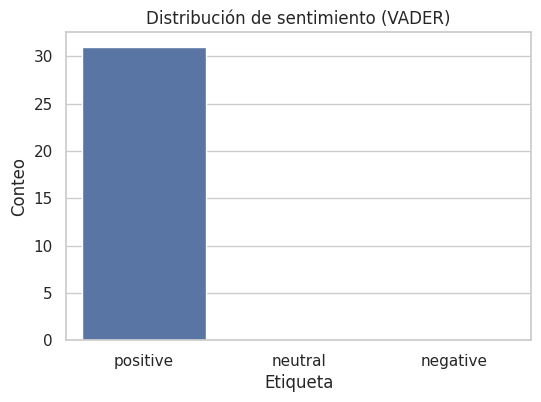

In [27]:
summary = results['compound_label'].value_counts().rename_axis('label').reset_index(name='count')
summary['pct'] = (summary['count'] / summary['count'].sum() * 100).round(2)
summary.to_csv('outputs/sentiment_summary.csv', index=False, encoding='utf-8-sig')
print(summary)

# Gráfico de barras
plt.figure(figsize=(6,4))
sns.countplot(data=results, x='compound_label', order=['positive','neutral','negative'])
plt.title('Distribución de sentimiento (VADER)')
plt.xlabel('Etiqueta')
plt.ylabel('Conteo')
plt.savefig('outputs/sentiment_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

In [28]:
# Crear nubes para cada etiqueta
os.makedirs('outputs/wordclouds', exist_ok=True)
stopwords = set(STOPWORDS)

for label in results['compound_label'].unique():
    text = ' '.join(
        (results[results['compound_label']==label]
         .fillna('')[ [abstract_col if abstract_col else title_col] ]
         .astype(str)
         .agg(' '.join, axis=1).tolist())
    ).lower()
    if not text.strip():
        continue
    wc = WordCloud(width=800, height=400, background_color='white',
                   stopwords=stopwords, collocations=True).generate(text)
    fname = f'outputs/wordclouds/wordcloud_{label}.png'
    wc.to_file(fname)
    print("Guardada", fname)

Guardada outputs/wordclouds/wordcloud_positive.png


In [29]:
rep = []
for label in ['positive','neutral','negative']:
    sub = results[results['compound_label']==label]
    if sub.shape[0]==0: continue
    sample = sub.sample(min(5, len(sub)), random_state=42)
    for _, r in sample.iterrows():
        rep.append({
            'label': label,
            'title': r.get(title_col,''),
            'abstract': r.get(abstract_col,''),
            'source': r.get('Source title','') if 'Source title' in r else ''
        })
rep_df = pd.DataFrame(rep)
rep_df.to_csv('outputs/representative_abstracts.csv', index=False, encoding='utf-8-sig')
print("Abstracts representativos guardados en outputs/representative_abstracts.csv")

Abstracts representativos guardados en outputs/representative_abstracts.csv


In [32]:
#(bash)
!ls -la outputs
!ls -la outputs/wordclouds || true

total 9404
drwxr-xr-x 3 root root    4096 May 25 01:48 .
drwxr-xr-x 1 root root    4096 May 25 01:46 ..
-rw-r--r-- 1 root root    6295 May 24 23:51 coauthor_communities.csv
-rw-r--r-- 1 root root   14175 May 24 23:51 coauthorship_top.html
-rw-r--r-- 1 root root 4569966 May 24 23:50 keyword_trends.html
-rw-r--r-- 1 root root      43 May 24 23:50 pubs_per_year.csv
-rw-r--r-- 1 root root 4567064 May 24 23:50 pubs_per_year.html
-rw-r--r-- 1 root root    7551 May 25 01:48 representative_abstracts.csv
-rw-r--r-- 1 root root   28065 May 25 01:48 sentiment_distribution.png
-rw-r--r-- 1 root root      37 May 25 01:48 sentiment_summary.csv
-rw-r--r-- 1 root root  385948 May 25 01:47 sentiment_vader_per_doc.csv
-rw-r--r-- 1 root root     561 May 24 23:50 top_authors.csv
-rw-r--r-- 1 root root     557 May 24 23:51 top_degree_authors.csv
-rw-r--r-- 1 root root     553 May 24 23:50 top_keywords.csv
-rw-r--r-- 1 root root     716 May 24 23:50 top_sources.csv
drwxr-xr-x 2 root root    4096 May 25 01:4

In [34]:
# Mostrar resumen y primeros abstracts representativos
import pandas as pd
pd.options.display.max_colwidth = 400

# Mostrar resumen
print("Resumen (sentiment_summary.csv):")
try:
    display(pd.read_csv('outputs/sentiment_summary.csv', encoding='utf-8-sig'))
except Exception as e:
    print("No se pudo leer sentiment_summary.csv:", e)

# Mostrar conteos por etiqueta desde el archivo principal
print("\nConteo por etiqueta (sentiment_vader_per_doc.csv):")
df = pd.read_csv('outputs/sentiment_vader_per_doc.csv', encoding='utf-8-sig')
print(df['compound_label'].value_counts(dropna=False))

# Mostrar primeros 10 registros con título, etiqueta y fragmento de abstract
text_col = next((c for c in df.columns if 'abstract' in c.lower()), None)
title_col = next((c for c in df.columns if 'title' in c.lower()), None)
cols_show = [c for c in [title_col, text_col, 'compound', 'compound_label'] if c is not None]
display(df[cols_show].head(20))

Resumen (sentiment_summary.csv):


,label,count,pct
0,positive,31,100.0



Conteo por etiqueta (sentiment_vader_per_doc.csv):
compound_label
positive    31
Name: count, dtype: int64


,Title,Abstract,compound,compound_label
0,Generative artificial intelligence and the challenges in the protection of personal data; [Inteligencia artificial generativa y los retos en la protección de los datos personales],"The article conducts an analysis concerning the vulnerability in the protection of personal data arising from the lack of a specialized legal framework capable of addressing technological advancements, particularly those devoid of an ethical perspective in their creation, promotion, and utilization. The focus is specifically on generative artificial intelligence, employing a human rights appro...",0.9780,positive
1,Survive GPT Chat. Reflections and proposals regarding the Master's Degree TFG; [Sobreviure al Xat GPT. Reflexions i propostes al voltant del TFG del grau de mestres]; [Sobrevivir al Chat GPT. Reflexiones y propuestas en torno al TFG del grado de maestros],"New technologies, such as online platforms and videoconferencing, have transformed higher education. Artificial Intelligence, including Chat GPT, offers personalized tutoring and automated assistance, although it poses ethical and security challenges that require appropriate regulations for responsible use in higher education. This research focuses on university-level teacher training, highlig...",0.8537,positive
2,"Acceptance of Generative AI in the creative industry: the role of UTAUT, brand recognition and trust in adoption; [Aceptación de la Inteligencia Artificial Generativa en la industria creativa: el rol del modelo UTAUT, reconocimiento y la confianza de marca en su adopción]","This study explores the factors influencing the adoption of Generative AI in the creative industry, focusing on the Unified Theory of Acceptance and Use of Technology (UTAUT) factors: performance expectancy, effort expectancy, facilitating conditions, social influence, and consumer-based brand equity factors: brand recognition and brand trust. While previous research has emphasized the importa...",0.9880,positive
3,"Ethics, Innovation, and Learning: Student Perspectives on Generative AI Adoption in University Practices; [Ética, Innovación y Aprendizaje: Perspectivas de los Estudiantes sobre la Adopción de la IA Generativa en las Prácticas Universitarias]","Generative artificial intelligence (AI), particularly ChatGPT, has reshaped learning processes in higher education by offering new opportunities alongside emerging challenges. Although its use has rapidly expanded, questions remain regarding how students integrate it into their academic practices, what perceptions they hold about its effectiveness, and which ethical implications arise from its...",0.9723,positive
4,Integration of generative artificial intelligence in sustainable higher education institutions: challenges and opportunities; [Integración de la inteligencia artificial generativa en las instituciones de educación superior sostenibles: desafíos y oportunidades],"The 21st century educational revolution driven by the advancement of Generative Artificial Intelligence (GAI), has radically transformed sustainable adaptive learning. The study analyzes the integration of GAI in Higher Education Institutions (HEIs) considering their challenges and opportunities in the implementation of educational technologies. A systematic bibliographic approach was applied ...",0.9058,positive
5,Enhancing University Lecturers’ Digital Competence through Generative Artificial Intelligence: A Quasi-Experimental Study in Peru; [Fortalecimiento de la competencia digital en docentes universitarios mediante inteligencia artificial generativa: estudio cuasiexperimental en Perú],"The post-COVID digital surge exposed a gap between 21st-century demands and Peruvian university lecturers’ actual technological skills, threatening educational quality advocated by SDG 4. This study examined whether generative artificial intelligence (GAI) enhances lecturers’ digital competence. A quasi-experimental pre/post-test design involved 60 lecture

In [35]:
# Descargar sólo archivos existentes (evita FileNotFoundError)
from google.colab import files
import os, glob

files_to_download = [
  'outputs/sentiment_vader_per_doc.csv',
  'outputs/sentiment_summary.csv',
  'outputs/sentiment_distribution.png',
  'outputs/representative_abstracts.csv',
]

# Añadir todos los png en outputs/wordclouds
wc_dir = 'outputs/wordclouds'
if os.path.isdir(wc_dir):
    for f in os.listdir(wc_dir):
        if f.endswith('.png'):
            files_to_download.append(os.path.join(wc_dir, f))

# Añadir html generados (coauthorship, keyword_trends, pubs_per_year)
for candidate in ['outputs/coauthorship_top.html','outputs/keyword_trends.html','outputs/pubs_per_year.html','outputs/coauthorship_top.html']:
    if os.path.exists(candidate):
        files_to_download.append(candidate)

for f in files_to_download:
    if os.path.exists(f):
        print("Descargando:", f)
        files.download(f)
    else:
        print("No existe, se omite:", f)

Descargando: outputs/sentiment_vader_per_doc.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: outputs/sentiment_summary.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: outputs/coauthorship_top.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
# Cargar resultados y detectar columnas
import pandas as pd, os
pd.options.display.max_colwidth = 300

res_path = 'outputs/sentiment_vader_per_doc.csv'
if not os.path.exists(res_path):
    raise SystemExit(f"No encuentro {res_path} — ejecuta primero el pipeline VADER.")

df = pd.read_csv(res_path, encoding='utf-8-sig')
# detectar columnas útiles
text_col = next((c for c in df.columns if 'abstract' in c.lower()), None)
title_col = next((c for c in df.columns if 'title' in c.lower()), None)
year_col = next((c for c in df.columns if 'year' in c.lower()), None)
search_col = 'search_text' if 'search_text' in df.columns else None

print("Columnas detectadas:", "title:", title_col, "abstract:", text_col, "year:", year_col, "search_text:", search_col)
print("\nConteo global por etiqueta:")
print(df['compound_label'].value_counts(dropna=False))
display(df[[title_col, text_col, 'compound','compound_label']].head(8))

Columnas detectadas: title: Title abstract: Abstract year: Year search_text: search_text

Conteo global por etiqueta:
compound_label
positive    31
Name: count, dtype: int64


,Title,Abstract,compound,compound_label
0,Generative artificial intelligence and the challenges in the protection of personal data; [Inteligencia artificial generativa y los retos en la protección de los datos personales],"The article conducts an analysis concerning the vulnerability in the protection of personal data arising from the lack of a specialized legal framework capable of addressing technological advancements, particularly those devoid of an ethical perspective in their creation, promotion, and utilizat...",0.9780,positive
1,Survive GPT Chat. Reflections and proposals regarding the Master's Degree TFG; [Sobreviure al Xat GPT. Reflexions i propostes al voltant del TFG del grau de mestres]; [Sobrevivir al Chat GPT. Reflexiones y propuestas en torno al TFG del grado de maestros],"New technologies, such as online platforms and videoconferencing, have transformed higher education. Artificial Intelligence, including Chat GPT, offers personalized tutoring and automated assistance, although it poses ethical and security challenges that require appropriate regulations for resp...",0.8537,positive
2,"Acceptance of Generative AI in the creative industry: the role of UTAUT, brand recognition and trust in adoption; [Aceptación de la Inteligencia Artificial Generativa en la industria creativa: el rol del modelo UTAUT, reconocimiento y la confianza de marca en su adopción]","This study explores the factors influencing the adoption of Generative AI in the creative industry, focusing on the Unified Theory of Acceptance and Use of Technology (UTAUT) factors: performance expectancy, effort expectancy, facilitating conditions, social influence, and consumer-based brand e...",0.9880,positive
3,"Ethics, Innovation, and Learning: Student Perspectives on Generative AI Adoption in University Practices; [Ética, Innovación y Aprendizaje: Perspectivas de los Estudiantes sobre la Adopción de la IA Generativa en las Prácticas Universitarias]","Generative artificial intelligence (AI), particularly ChatGPT, has reshaped learning processes in higher education by offering new opportunities alongside emerging challenges. Although its use has rapidly expanded, questions remain regarding how students integrate it into their academic practice...",0.9723,positive
4,Integration of generative artificial intelligence in sustainable higher education institutions: challenges and opportunities; [Integración de la inteligencia artificial generativa en las instituciones de educación superior sostenibles: desafíos y oportunidades],"The 21st century educational revolution driven by the advancement of Generative Artificial Intelligence (GAI), has radically transformed sustainable adaptive learning. The study analyzes the integration of GAI in Higher Education Institutions (HEIs) considering their challenges and opportunities...",0.9058,positive
5,Enhancing University Lecturers’ Digital Competence through Generative Artificial Intelligence: A Quasi-Experimental Study in Peru; [Fortalecimiento de la competencia digital en docentes universitarios mediante inteligencia artificial generativa: estudio cuasiexperimental en Perú],"The post-COVID digital surge exposed a gap between 21st-century demands and Peruvian university lecturers’ actual technological skills, threatening educational quality advocated by SDG 4. This study examined whether generative artificial intelligence (GAI) enhances lecturers’ digital competence....",0.9349,positive
6,"Impact of Generative Artificial Intelligence on the efficiency, quality, and innovation in the production of Open Educational Resources for moocs; [Impacto da Inteligência Artificial Generativa na eficiência, qualidade e inovação na produção de Recursos Educacionais Abertos para moocs]; [Impacto...","The research analyzes the impact of Generative Artificial Intelligence (gai) in the creation of audiovisual and multimedia content through a comparative study of Open Educational Resources (oer) developed in two moocs (n = 121) focused 

In [37]:
# Sentimiento por keyword
import re, csv
keywords = ["privacidad","privacy","costo","cost","adopción","adoption","seguridad","security"]

# asegúrate de tener un campo combinado de búsqueda (si no lo hay construyelo)
if search_col is None:
    used_cols = [c for c in [title_col, text_col, 'Author Keywords', 'Author keywords', 'Keywords'] if c in df.columns]
    if not used_cols:
        # crea a partir de title+abstract
        df['search_text'] = df[[c for c in [title_col, text_col] if c is not None]].fillna('').agg(' '.join, axis=1).str.lower()
    else:
        df['search_text'] = df[used_cols].fillna('').agg(' '.join, axis=1).str.lower()

pattern = '|'.join([re.escape(k.lower()) for k in keywords])

rows = []
for k in keywords:
    mask = df['search_text'].str.contains(re.escape(k.lower()), na=False)
    sub = df[mask]
    total = len(sub)
    if total == 0:
        rows.append({'keyword': k, 'total': 0, 'positive':0,'neutral':0,'negative':0,'pct_negative':0.0})
        continue
    counts = sub['compound_label'].value_counts()
    pos = int(counts.get('positive',0))
    neu = int(counts.get('neutral',0))
    neg = int(counts.get('negative',0))
    rows.append({'keyword': k, 'total': total, 'positive': pos, 'neutral': neu, 'negative': neg,
                 'pct_negative': round(100*neg/total,2)})

df_kw = pd.DataFrame(rows).sort_values(['total','pct_negative'], ascending=[False, False])
df_kw.to_csv('outputs/sentiment_by_keyword.csv', index=False, encoding='utf-8-sig')
print("Guardado: outputs/sentiment_by_keyword.csv")
display(df_kw)

Guardado: outputs/sentiment_by_keyword.csv


,keyword,total,positive,neutral,negative,pct_negative
5,adoption,17,17,0,0,0.0
1,privacy,11,11,0,0,0.0
7,security,7,7,0,0,0.0
4,adopción,4,4,0,0,0.0
3,cost,2,2,0,0,0.0
0,privacidad,0,0,0,0,0.0
2,costo,0,0,0,0,0.0
6,seguridad,0,0,0,0,0.0


Guardado: outputs/sentiment_by_year.csv
Guardado: outputs/sentiment_by_year.png


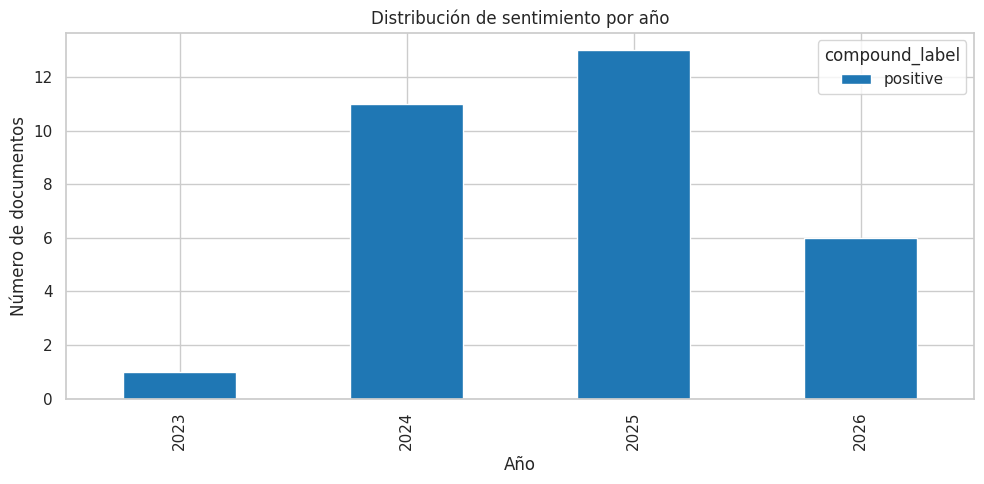

In [38]:
# Celda 3 - Sentimiento por año
import matplotlib.pyplot as plt
if year_col is None:
    print("No se detectó columna 'Year'. Revisa df.columns para identificarla.")
else:
    df_year = df[[year_col,'compound_label']].dropna(subset=[year_col])
    # normalizar year a int si es posible
    df_year[year_col] = pd.to_numeric(df_year[year_col], errors='coerce').dropna().astype(int)
    pivot = df_year.groupby([year_col,'compound_label']).size().unstack(fill_value=0)
    pivot.to_csv('outputs/sentiment_by_year.csv', encoding='utf-8-sig')
    print("Guardado: outputs/sentiment_by_year.csv")
    # gráfico apilado
    pivot.plot(kind='bar', stacked=True, figsize=(10,5), colormap='tab20')
    plt.title('Distribución de sentimiento por año')
    plt.xlabel('Año')
    plt.ylabel('Número de documentos')
    plt.tight_layout()
    plt.savefig('outputs/sentiment_by_year.png', dpi=150)
    print("Guardado: outputs/sentiment_by_year.png")
    plt.show()

In [39]:
# Tokens más frecuentes en abstracts negative
from collections import Counter
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
import re
from wordcloud import WordCloud, STOPWORDS

neg_df = df[df['compound_label']=='negative']
if neg_df.empty:
    print("No hay documentos etiquetados como 'negative'. Considera re-etiquetar con umbrales más sensibles si esperas negatives.")
else:
    # concatenar textos (usar abstract si existe)
    text_field = text_col if text_col is not None else title_col
    corpus = ' '.join(neg_df[text_field].fillna('').astype(str).tolist()).lower()
    # limpieza simple
    corpus = re.sub(r'\b\d+\b',' ', corpus)
    tokens = re.findall(r'\b[a-záéíóúñü]{3,}\b', corpus)
    stops = set(stopwords.words('spanish')) | set(stopwords.words('english')) | set(STOPWORDS)
    tokens = [t for t in tokens if t not in stops]
    top = Counter(tokens).most_common(50)
    pd.DataFrame(top, columns=['token','count']).to_csv('outputs/top_negative_tokens.csv', index=False, encoding='utf-8-sig')
    print("Guardado: outputs/top_negative_tokens.csv")
    # generar nube
    if corpus.strip():
        wc = WordCloud(width=1200, height=600, background_color='white', stopwords=stops).generate(corpus)
        os.makedirs('outputs/wordclouds', exist_ok=True)
        wc_path = 'outputs/wordclouds/wordcloud_negative_from_text.png'
        wc.to_file(wc_path)
        print("Nube guardada:", wc_path)

No hay documentos etiquetados como 'negative'. Considera re-etiquetar con umbrales más sensibles si esperas negatives.


In [40]:
# Celda 5 - Informe automatizado (resumen + hallazgos por keyword + recomendaciones)
import datetime
now = datetime.datetime.now().strftime("%Y-%m-%d %H:%M")
# lectura util
summary = pd.read_csv('outputs/sentiment_summary.csv', encoding='utf-8-sig') if os.path.exists('outputs/sentiment_summary.csv') else None
kw = pd.read_csv('outputs/sentiment_by_keyword.csv', encoding='utf-8-sig') if os.path.exists('outputs/sentiment_by_keyword.csv') else None

lines = []
lines.append(f"# Informe automático de sentimiento - Paso 6\nFecha: {now}\n")
lines.append("## Resumen general\n")
if summary is not None:
    lines.append(summary.to_string(index=False))
else:
    lines.append("No existe sentiment_summary.csv — revisa pipeline.\n")
lines.append("\n## Hallazgos por palabra clave (porcentaje de negativos)\n")
if kw is not None:
    lines.append(kw.to_string(index=False))
else:
    lines.append("No existe sentiment_by_keyword.csv\n")

# Hallazgos rápidos programáticos
lines.append("\n## Hallazgos rápidos (automático)\n")
# keyword con mayor % negative (si existe)
if kw is not None and kw['total'].sum()>0:
    kw_nonzero = kw[kw['total']>0].sort_values('pct_negative', ascending=False)
    top_risk = kw_nonzero.iloc[0]
    lines.append(f"- Keyword con mayor proporción de negativos: {top_risk['keyword']} ({top_risk['pct_negative']}% negativos sobre {top_risk['total']} doc.)")
else:
    lines.append("- No hay documentos con keywords para analizar proporción de negativos.")
# tendencias
if os.path.exists('outputs/sentiment_by_year.csv'):
    sy = pd.read_csv('outputs/sentiment_by_year.csv', encoding='utf-8-sig', index_col=0)
    # calcular pct negative por año
    sy['total'] = sy.sum(axis=1)
    if 'negative' in sy.columns:
        sy['pct_negative'] = (sy['negative'] / sy['total'] * 100).round(2)
        recent = sy.sort_index(ascending=False).head(3)
        lines.append(f"- Últimos años (máx 3) % negative:\n{recent['pct_negative'].to_string()}")
lines.append("\n## Recomendaciones operativas\n")
lines += [
    "- Revisar manualmente los abstracts negativos representativos (outputs/representative_abstracts.csv).",
    "- Expandir lista de keywords y sinónimos si detectas falsos negativos/positivos.",
    "- Si necesitas mayor sensibilidad en español, considerar modelo Transformer multilingüe.",
    "- Priorizar análisis por keyword con mayor % negative para construir alertas o dashboards.",
]

out_txt = '\n\n'.join(lines)
with open('outputs/sentiment_report.md','w', encoding='utf-8') as f:
    f.write(out_txt)
with open('outputs/sentiment_report.txt','w', encoding='utf-8') as f:
    f.write(out_txt)

print("Informe guardado: outputs/sentiment_report.md  y .txt")
print("\n--- Inicio del informe ---\n")
print(out_txt[:2000])

Informe guardado: outputs/sentiment_report.md  y .txt

--- Inicio del informe ---

# Informe automático de sentimiento - Paso 6
Fecha: 2026-05-25 01:57


## Resumen general


   label  count   pct
positive     31 100.0


## Hallazgos por palabra clave (porcentaje de negativos)


   keyword  total  positive  neutral  negative  pct_negative
  adoption     17        17        0         0           0.0
   privacy     11        11        0         0           0.0
  security      7         7        0         0           0.0
  adopción      4         4        0         0           0.0
      cost      2         2        0         0           0.0
privacidad      0         0        0         0           0.0
     costo      0         0        0         0           0.0
 seguridad      0         0        0         0           0.0


## Hallazgos rápidos (automático)


- Keyword con mayor proporción de negativos: adoption (0.0% negativos sobre 17 doc.)


## Recomendaciones operativas


- Revisar manu